In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor


# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [2]:
# 💾 저장 파일 이름
best_model_path = 'model/best_model_final12_6.dat'

# 🔁 교차검증 횟수
cv_count = 10
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)

f1_score_list = []
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [3]:
# 데이터를 읽어온다.
train_df = pd.read_csv('model3_train_CD(4).csv')
test_df = pd.read_csv('model3_test_CD(4).csv')

display(train_df)
display(test_df)

,_1순위카드이용금액,연령,이용금액_R3M_신용체크,이용카드수_신용체크,소지카드수_유효_신용,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,이용금액_일시불_R12M,이용금액대,청구금액_R6M,평잔_일시불_3M
0,3681,40대,196,1,1,0,0,0,20667,100,88693,1791
1,24493,30대,23988,1,1,1,1,0,55656,100,165221,6796
2,5933,40대,3904,1,2,1,1,0,10753,100,127371,772
3,68078,30대,124967,5,3,1,1,1,360859,100,94241,28376
4,18796,40대,21001,1,1,1,1,0,34884,100,35723,20399
...,...,...,...,...,...,...,...,...,...,...,...,...
477943,27337,40대,31187,2,2,1,1,1,85901,100,74153,4738
477944,35751,50대,42492,1,1,1,1,0,90222,100,132623,3609
477945,27792,40대,72348,4,3,1,1,1,169672,100,72474,15212
477946,26357,50대,27636,1,1,1,1,0,148106,100,99849,9424


,청구금액_R6M,이용금액_일시불_R12M,_1순위카드이용금액,이용금액대,연령,이용금액_R3M_신용체크,이용카드수_신용체크,소지카드수_유효_신용,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,평잔_일시불_3M
0,22151,49063,13852,50,40대,21458,2,2,1,1,1,3841
1,32878,7771,11065,50,60대,18681,2,1,1,1,0,844
2,71867,73003,27071,100,40대,40758,2,2,0,0,0,5606
3,4986,7421,4827,10,40대,5255,1,1,1,1,0,1510
4,10758,10493,8011,30,40대,16148,3,1,1,1,1,1373
...,...,...,...,...,...,...,...,...,...,...,...,...
599995,0,0,0,0,60대,0,0,0,0,0,0,0
599996,2237,2631,1231,5,30대,3110,1,1,0,0,0,237
599997,0,0,0,0,30대,0,0,1,0,0,0,0
599998,108420,423882,63592,100,30대,173263,6,3,1,1,1,17039


In [4]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,_1순위카드이용금액,연령,이용금액_R3M_신용체크,이용카드수_신용체크,소지카드수_유효_신용,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,이용금액_일시불_R12M,이용금액대,청구금액_R6M,평잔_일시불_3M
0,3681,40대,196,1,1,0,0,0,20667,100,88693,1791
1,24493,30대,23988,1,1,1,1,0,55656,100,165221,6796
2,5933,40대,3904,1,2,1,1,0,10753,100,127371,772
3,68078,30대,124967,5,3,1,1,1,360859,100,94241,28376
4,18796,40대,21001,1,1,1,1,0,34884,100,35723,20399
...,...,...,...,...,...,...,...,...,...,...,...,...
1077943,0,60대,0,0,0,0,0,0,0,0,0,0
1077944,1231,30대,3110,1,1,0,0,0,2631,5,2237,237
1077945,0,30대,0,0,1,0,0,0,0,0,0,0
1077946,63592,30대,173263,6,3,1,1,1,423882,100,108420,17039


In [5]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077948 entries, 0 to 1077947
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   _1순위카드이용금액      1077948 non-null  int64 
 1   연령              1077948 non-null  object
 2   이용금액_R3M_신용체크   1077948 non-null  int64 
 3   이용카드수_신용체크      1077948 non-null  int64 
 4   소지카드수_유효_신용     1077948 non-null  int64 
 5   이용가능여부_해외겸용_본인  1077948 non-null  int64 
 6   보유여부_해외겸용_본인    1077948 non-null  int64 
 7   수신거부여부_TM       1077948 non-null  int64 
 8   이용금액_일시불_R12M   1077948 non-null  int64 
 9   이용금액대           1077948 non-null  int64 
 10  청구금액_R6M        1077948 non-null  int64 
 11  평잔_일시불_3M       1077948 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 98.7+ MB


In [6]:
# LabelEncoder 학습
Encoder1 = LabelEncoder()

Encoder1.fit(all_df['연령'])

LabelEncoder()

In [7]:
train_df['연령'] = Encoder1.transform(train_df['연령'])

In [8]:
# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(train_df)

,copy,True
,with_mean,True
,with_std,True


In [9]:
target1=pd.read_parquet(r'data/train/1.회원정보/201807_train_.parquet')
target2=pd.read_parquet(r'data/train/1.회원정보/201808_train_.parquet')
target3=pd.read_parquet(r'data/train/1.회원정보/201809_train_.parquet')
target4=pd.read_parquet(r'data/train/1.회원정보/201810_train_.parquet')
target5=pd.read_parquet(r'data/train/1.회원정보/201811_train_.parquet')
target6=pd.read_parquet(r'data/train/1.회원정보/201812_train_.parquet')

In [10]:
tg_df = pd.concat([
    target1['Segment'],
    target2['Segment'],
    target3['Segment'],
    target4['Segment'],
    target5['Segment'],
    target6['Segment']
])

tg_df = tg_df.reset_index(drop=True).to_frame(name='Segment')
tg_df = tg_df[tg_df['Segment'] != 'E']

tg_df['Segment'] = tg_df['Segment'].apply(
    lambda x: x if x in ['C', 'D'] else 'notCD'
)
tg_df

,Segment
0,D
2,C
3,D
8,C
10,D
...,...
2399979,D
2399987,C
2399993,C
2399996,D


In [11]:
tg_df2=tg_df.copy()

In [12]:
X = train_df

X_train, X_val, y_train, y_val = train_test_split(
    X, tg_df2,
    test_size=0.2,
    random_state=42,
    stratify=tg_df2  # 클래스 비율 유지하려면 추가
)

In [16]:
y_train2=y_train.copy()
y_val2=y_val.copy()

In [17]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
y_train['Segment'] = le.fit_transform(y_train['Segment'])
y_val['Segment'] = le.fit_transform(y_val['Segment'])

In [18]:
X = X_train
y = y_train

In [19]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[ 0.47829853, -0.02292474, -0.3712191 , ...,  0.84067571,
        -0.24730707,  0.50406633],
       [-1.15208765, -0.02292474, -1.29251463, ..., -1.64069168,
        -1.05039881, -0.79054441],
       [ 0.53652847, -0.02292474,  0.54922901, ...,  0.84067571,
        -0.20471888,  0.26534439],
       ...,
       [-0.04702206, -0.02292474,  0.04382525, ...,  0.84067571,
        -0.27735641,  0.0084765 ],
       [-0.50634525, -0.02292474, -0.6291467 , ..., -0.53786173,
        -0.45751506, -0.67627629],
       [-0.56984038, -0.91459428, -0.86318978, ..., -0.53786173,
        -0.56287999, -0.4512494 ]])

In [20]:
train_X = X2
train_y = y

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [21]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import joblib  # 모델 저장용

In [22]:
import pandas as pd
import numpy as np

# y_train2가 DataFrame일 때
y_train2_flat = y_train2.values.ravel()

# 결측치 확인
print("결측치 개수:", pd.Series(y_train2_flat).isna().sum())
print("고유 값 목록:", pd.Series(y_train2_flat).unique())

결측치 개수: 0
고유 값 목록: ['D' 'C' 'notCD']


In [56]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import cross_val_score, KFold
from lightgbm import LGBMClassifier
import numpy as np

# 1차원 라벨
y_train2_flat = y_train2.values.ravel()

# 클래스 목록 추출
classes = np.unique(y_train2_flat)

# 클래스별 가중치 계산
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train2_flat)
class_weight_dict = {
    'C': 1.0,
    'D': 0.7,
    'notCD': 5.0  # 기존 142 → 5~10 수준으로 낮춰보기
}
print("클래스별 가중치:", class_weight_dict)

# ✅ LGBM 모델 정의
model5 = LGBMClassifier(
    device='cpu',
    objective='multiclass',
    num_class=3,
    class_weight=class_weight_dict,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    verbose=-1
)

# ✅ 교차 검증 설정
cv_count = 10
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)

# ✅ cross_val_score로 f1_micro 평가
r1 = cross_val_score(model5, train_X, y_train2_flat, scoring='f1_micro', cv=kfold)

# ✅ 결과 출력 및 저장
print(f'평균 f1 Score : {r1.mean():.4f}')
f1_score_list.append(r1.mean())
model_name_list.append("LGBMClassifier + class_weight")

클래스별 가중치: {'C': 1.0, 'D': 0.7, 'notCD': 5.0}
평균 f1 Score : 0.7928


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

y_train_encoded = le.fit_transform(y_train2_flat)

# 확인
print("인코딩된 클래스:", le.classes_)  # ['C', 'D', 'notCD'] → [0, 1, 2]

model6 = XGBClassifier(
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=3
)

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r2 = cross_val_score(model6, train_X, y_train_encoded, scoring='f1_micro', cv=kfold)

print(f'평균 f1 Score : {r2.mean():.4f}')
f1_score_list.append(r2.mean())
model_name_list.append("XGBClassifier")

인코딩된 클래스: ['C' 'D' 'notCD']
평균 f1 Score : 0.7977


In [25]:
df = pd.DataFrame({
    'Model': model_name_list,
    'f1 score': f1_score_list
})
df = df.dropna()

In [26]:
df

,Model,f1 score
0,LGBMClassifier + class_weight,0.745495
1,XGBClassifier,0.797697


In [57]:
final_model1=model5.fit(train_X, y_train2_flat)
final_model2=model6.fit(train_X, y_train_encoded)

In [58]:
with open(best_model_path, 'wb') as fp:
    pickle.dump(model5, fp)
    pickle.dump(model6, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(Encoder1, fp)
    pickle.dump(le, fp)  # ← LabelEncoder 객체 추가

print('저장완료')

저장완료


In [59]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/best_model_final12_6.dat'
# 예측 결과를 저장할 파일 이름
prediction_path = 'model/final_prediction12_6.csv'

In [60]:
with open(best_model_path, 'rb') as fp :
    model5 = pickle.load(fp)
    model6 = pickle.load(fp)
    scalerX = pickle.load(fp)
    Encoder1 = pickle.load(fp)
    SegmentEncoder = pickle.load(fp)

display(model5)
display(model6)
display(scalerX)
display(Encoder1)
display(SegmentEncoder)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,"{'C': 1.0, 'D': 0.7, 'notCD': 5.0}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


,copy,True
,with_mean,True
,with_std,True


LabelEncoder()

LabelEncoder()

In [61]:
mat_X = X_val
mat_y = y_val2

In [62]:
mat_y['Segment'].value_counts()

Segment
D        69849
C        25518
notCD      223
Name: count, dtype: int64

In [63]:
y_train_encoded1 = SegmentEncoder.fit_transform(mat_y)

In [64]:
y_train_encoded1

array([1, 1, 1, ..., 1, 0, 1])

In [65]:
y_pred_train1 = model5.predict(mat_X)
y_pred_train2 = model6.predict(mat_X)

### model5

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [67]:
y_true_labels1 = SegmentEncoder.inverse_transform(y_train_encoded1)

In [68]:
y_pred_train1

array(['notCD', 'notCD', 'notCD', ..., 'notCD', 'notCD', 'notCD'],
      dtype=object)

In [69]:
y_true_labels1

array(['D', 'D', 'D', ..., 'D', 'C', 'D'], dtype=object)

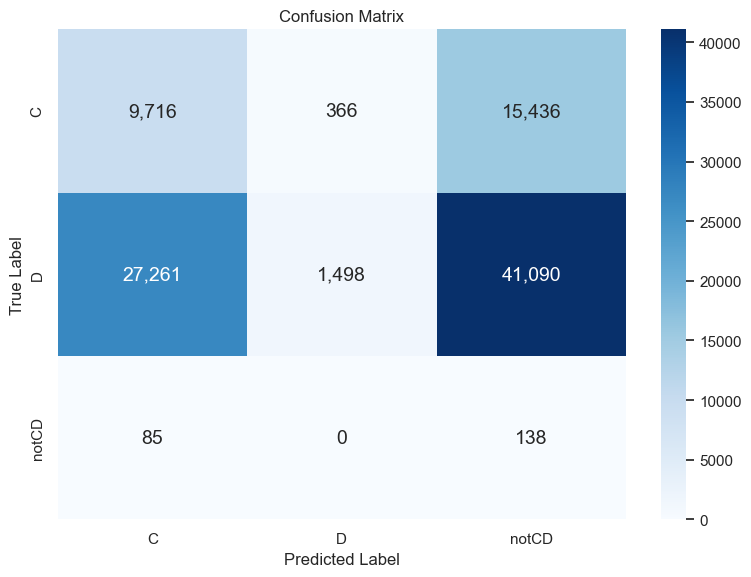

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 안전하게 라벨 추출
labels = list(np.unique(y_true_labels1))

# 혼동 행렬
cm = confusion_matrix(y_true_labels1, y_pred_train1, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()